# QTCAD M04 Lever Arm — Result Analysis (심화판)

M04에는 전용 공식 튜토리얼이 없습니다. `qtcad.device.leverarm`(단일 게이트, 전압 스윕 +
선형/다항 피팅)과 `qtcad.device.leverarm_matrix`(여러 게이트, 유한 차분)를
M03의 FD-SOI 이중양자점(`get_double_dot_fdsoi`)에 그대로 적용합니다
(`leverarm_fdsoi.py`, 사용법은 `examples/practical_application/GaAs_gated/4-lever_arm.py` 참고).

**이 노트북에서 실제로 수행한 분석 (요약)**
- `dqdfdsoi.geo` 치수로 **소자 스케매틱**(M16과 동일 소자, 게이트 배치 재확인) (0절)
- 레버암의 **고전적 정의**(capacitive voltage divider)와 QTCAD의 두 계산 방식(선형 피팅 vs
  유한차분)의 **수식적 차이**를 명시 (1절)
- 단일 게이트 레버암(선형 피팅)과 5-게이트 cross-coupling 행렬(유한차분)을 각각 분석 (2-3절)
- 두 방법의 **정량적 불일치를 메시 해상도 관점에서 근본 원인 분석** (4절)
- 모든 그림·표를 `output/analysis_exports/`에 저장 (5절)

**메시 선택에 대한 안내**: 이 계산은 독립적인 Poisson+Schrödinger 풀이가 약 11번 필요해서
(스윕 5점 + 유한차분 6점), M03이 쓰는 적응형으로 재정제된 메시(45 MB, 단일 production point용)
대신 재정제 전의 기본 `dqdfdsoi.msh`를 썼습니다. 레버암은 에너지의 *기울기*(dE/dV)라서
절대 에너지보다 메시 정제도에 덜 민감하다고 보고 내린 선택입니다 — M03 자체의 메시를
바꾼 것은 아닙니다.

---
## 📚 참고 문서
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- **실제 사용 패턴 참고** — Practical Application GaAs Part 4: Lever arm
  (`examples/practical_application/GaAs_gated/4-lever_arm.py`, 설치 패키지 내 포함)
- **소자 구조** — A double quantum dot device in FD-SOI
  https://docs.nanoacademic.com/qtcad/tutorials/device/double_dot_fdsoi/
- 소스 스크립트: `leverarm_fdsoi.py` (이번 세션에 직접 작성, M04/Reference)
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M04. Lever arm\Reference`

목차:
0. 소자 스케매틱 + 파라미터 선택 의도
1. 레버암의 물리적 정의 — Capacitive Voltage Divider 모형
2. 단일 게이트 레버암 (선형 피팅)
3. 5-게이트 Cross-Coupling 행렬 (유한차분)
4. 두 방법 불일치의 근본 원인 분석
5. 최종 요약


In [1]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M04. Lever arm\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FILE_SINGLE_TXT = OUTPUT_DIR / "leverarm_plunger_gate_1.txt"
FILE_SINGLE_PNG = OUTPUT_DIR / "leverarm_plunger_gate_1.png"
FILE_MATRIX_TXT = OUTPUT_DIR / "leverarm_matrix.txt"
FILE_LABELS = OUTPUT_DIR / "leverarm_matrix_labels.txt"

ct_e = 1.602176634e-19

print("BASE_DIR :", BASE_DIR)
assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
print("\n[OK] 기본 경로 확인 완료")


BASE_DIR : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M04. Lever arm\Reference

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {
    "leverarm_plunger_gate_1.txt": FILE_SINGLE_TXT, "leverarm_plunger_gate_1.png": FILE_SINGLE_PNG,
    "leverarm_matrix.txt": FILE_MATRIX_TXT, "leverarm_matrix_labels.txt": FILE_LABELS,
}
rows = []
for label, path in expected_files.items():
    rows.append({"file": label, "exists": path.exists(),
                "size_B": path.stat().st_size if path.exists() else np.nan})
inventory_df = pd.DataFrame(rows)
display(inventory_df)
missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
print("\n[주의] 없는 파일:" if missing else "\n[OK] 분석 대상 파일이 모두 존재합니다.", missing or "")


,file,exists,size_B
0,leverarm_plunger_gate_1.txt,True,117
1,leverarm_plunger_gate_1.png,True,95138
2,leverarm_matrix.txt,True,1322
3,leverarm_matrix_labels.txt,True,98



[OK] 분석 대상 파일이 모두 존재합니다. 


## 0. 소자 스케매틱 + 파라미터 선택 의도

M16과 동일한 FD-SOI 이중양자점 소자입니다 (`dqdfdsoi.geo` 치수 공식, 상세 유도는
M16 0절 참고). 여기서는 plunger_gate_1(dot1 플런저)을 중심으로 분석합니다.

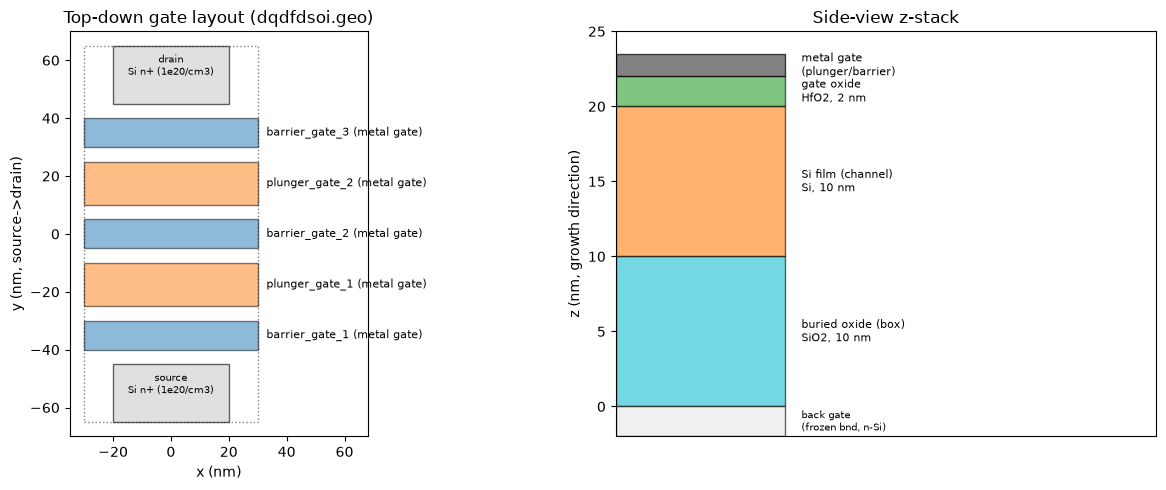

,parameter,intent
0,"plunger_gate_1 sweep: 0.56-0.62 V, 5점 (기준 0.59V)",M03의 기준 바이어스(0.59V) 주변 ±30mV의 좁은 창 — 선형 영역(국소 ...
1,bias_increment=1e-3 V (유한차분),"충분히 작아 선형 근사가 유효하면서도, Poisson/Schrödinger 수치 노..."
2,mesh: un-refined dqdfdsoi.msh (M03/M16의 refine...,11번의 독립 풀이를 감당할 수 있는 속도(0.1s/Poisson iter) 확보....


In [3]:
domain_width, channel_width = 60.0, 40.0
gaps = [5.0] * 6
barrier_len, plunger_len, sd_len = 10.0, 15.0, 20.0
channel_len = sum(gaps) + 3 * barrier_len + 2 * plunger_len
domain_len = 2 * sd_len + channel_len
temp = -channel_len / 2 + gaps[0]
lens = [barrier_len, plunger_len, barrier_len, plunger_len, barrier_len]
names = ["barrier_gate_1", "plunger_gate_1", "barrier_gate_2", "plunger_gate_2", "barrier_gate_3"]
segs = []
for name, L, gi in zip(names, lens, [1, 2, 3, 4, 5]):
    segs.append((name, temp, temp + L)); temp = temp + gaps[gi] + L

fig, axs = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axs[0]
ax.add_patch(mpatches.Rectangle((-domain_width/2, -domain_len/2), domain_width, domain_len,
                                fill=False, ls=":", ec="0.5"))
ax.add_patch(mpatches.Rectangle((-channel_width/2, -domain_len/2), channel_width, sd_len,
                                fc="0.8", alpha=0.6, ec="k"))
ax.add_patch(mpatches.Rectangle((-channel_width/2, domain_len/2 - sd_len), channel_width, sd_len,
                                fc="0.8", alpha=0.6, ec="k"))
ax.text(0, -domain_len/2 + sd_len/2, "source\nSi n+ (1e20/cm3)", ha="center", fontsize=7)
ax.text(0, domain_len/2 - sd_len/2, "drain\nSi n+ (1e20/cm3)", ha="center", fontsize=7)
for name, y0, y1 in segs:
    ax.add_patch(mpatches.Rectangle((-domain_width/2, y0), domain_width, y1 - y0,
                                    fc="tab:orange" if "plunger" in name else "tab:blue",
                                    alpha=0.5, ec="k"))
    ax.text(domain_width/2 + 3, (y0 + y1) / 2, name + " (metal gate)", va="center", fontsize=8)
ax.set_xlim(-domain_width/2-5, domain_width/2+38); ax.set_ylim(-domain_len/2-5, domain_len/2+5)
ax.set_aspect("equal"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm, source->drain)")
ax.set_title("Top-down gate layout (dqdfdsoi.geo)")

ax2 = axs[1]
z_layers = [("buried oxide (box)\nSiO2, 10 nm", 10, "tab:cyan"),
           ("Si film (channel)\nSi, 10 nm", 10, "tab:orange"),
           ("gate oxide\nHfO2, 2 nm", 2, "tab:green")]
z0 = 0
for name, thick, color in z_layers:
    ax2.add_patch(mpatches.Rectangle((0, z0), 1, thick, fc=color, alpha=0.6, ec="k"))
    ax2.text(1.1, z0 + thick/2, name, va="center", fontsize=8)
    z0 += thick
ax2.add_patch(mpatches.Rectangle((0, z0), 1, 1.5, fc="0.3", alpha=0.7, ec="k"))
ax2.text(1.1, z0 + 0.75, "metal gate\n(plunger/barrier)", va="center", fontsize=8)
ax2.set_xlim(0, 3.2); ax2.set_ylim(-2, z0 + 3)
ax2.add_patch(mpatches.Rectangle((0, -2), 1, 2, fc="0.9", alpha=0.6, ec="k"))
ax2.text(1.1, -1, "back gate\n(frozen bnd, n-Si)", va="center", fontsize=7)
ax2.set_xticks([]); ax2.set_ylabel("z (nm, growth direction)")
ax2.set_title("Side-view z-stack")
fig.tight_layout()

fig.savefig(EXPORT_DIR / "device_schematic_top_view.png", dpi=150)
plt.show()

param_intent = pd.DataFrame([
    {"parameter": "plunger_gate_1 sweep: 0.56-0.62 V, 5점 (기준 0.59V)",
     "intent": "M03의 기준 바이어스(0.59V) 주변 ±30mV의 좁은 창 — 선형 영역(국소 기울기)만 "
               "보려는 의도. 너무 넓히면 비선형(4절) 영향이 커짐."},
    {"parameter": "bias_increment=1e-3 V (유한차분)",
     "intent": "충분히 작아 선형 근사가 유효하면서도, Poisson/Schrödinger 수치 노이즈보다는 "
               "큰 중간값 — 4절에서 이 선택이 un-refined 메시와 만나 문제가 되는 과정을 분석."},
    {"parameter": "mesh: un-refined dqdfdsoi.msh (M03/M16의 refined 메시 대신)",
     "intent": "11번의 독립 풀이를 감당할 수 있는 속도(0.1s/Poisson iter) 확보. 레버암은 "
               "기울기라 메시 민감도가 낮을 것으로 예상했으나 — 4절에서 이 가정 자체를 "
               "검증합니다."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


## 1. 레버암의 물리적 정의 — Capacitive Voltage Divider 모형

고전적으로, 게이트 $a$의 레버암은 그 게이트가 양자점 전위에 기여하는 커패시턴스 분할
비율로 정의됩니다:
$$
\alpha_a = \frac{C_{a,\mathrm{dot}}}{C_{\mathrm{dot}}^{\Sigma}}
$$
($C_{a,\mathrm{dot}}$=게이트 $a$-dot 상호 커패시턴스, $C_{\mathrm{dot}}^\Sigma$=dot의
총 커패시턴스). QTCAD는 이를 직접 커패시턴스로 계산하지 않고, 에너지가 전압에 대해
$\Delta E = e\alpha\, \Delta V$로 선형 반응한다는 동등한 정의를 씁니다 — 즉
"게이트 전압 1 V 변화가 dot 에너지를 몇 eV 바꾸는가"의 비율입니다:
- **`leverarm.Solver`** (2절): 전압 $N$점을 스윕해 $E_0(V)$에 1차 다항 피팅
  $E_0 = mV+b$ (단위 J, V), $\alpha=|m|/e$ (docstring 명시: "Units employed for the fit
  are J for energy and V for voltage").
- **`leverarm_matrix.Solver`** (3절): 기준점에서 각 게이트를 $\delta V$(=`bias_increment`)만
  살짝 바꿔 $\alpha_{ia} \approx \dfrac{E_i(V_a+\delta V)-E_i(V_a)}{e\,\delta V}$ 유한차분으로
  근사 — 이미 무차원 레버암 값을 직접 반환합니다(저장 파일을 직접 확인해 `/e`가 중복
  적용되지 않도록 함, 4절 참고).

## 2. 단일 게이트 레버암 (선형 피팅)

plunger_gate_1_bnd를 0.56~0.62 V(기준점 0.59 V 주변) 5점 스윕하고, 바닥상태 에너지에
1차 다항 피팅을 해서 기울기(레버암)를 구합니다.

선형 피팅: E0(V) = -3.3175e-20 * V + 2.9727e-20  (J, V)
plunger_gate_1 레버암 (|slope|/e) = 0.2071


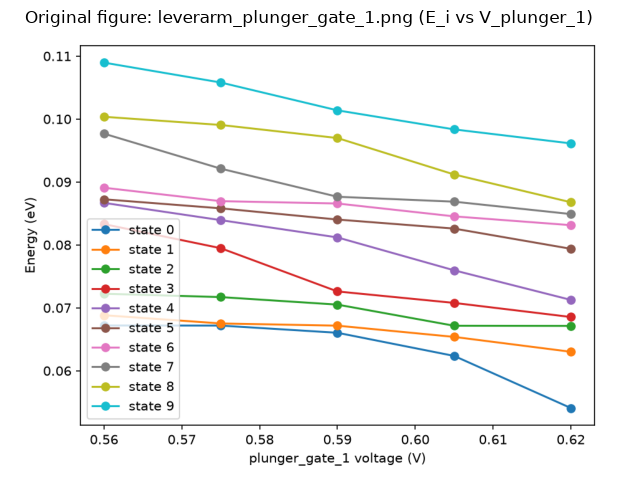


[해석] 레버암 ~0.2 수준이면, 플런저 게이트 전압 1V 변화가 dot 1의 에너지를 약 0.2 eV 바꾼다는 뜻입니다. 1보다 훨씬 작은 것은 게이트와 dot 사이의 산화막·다른 게이트의 차폐(screening) 효과 때문입니다(1절의 $C_{a,dot}/C^\Sigma$ 식에서, 다른 게이트들도 dot에 커패시턴스로 기여해 분모를 키우므로).


In [4]:
# [동작] 단일 게이트 레버암 피팅 계수 로드
coeffs = np.loadtxt(FILE_SINGLE_TXT)
slope_J_per_V, intercept_J = coeffs[0], coeffs[1]
lever_arm_single = abs(slope_J_per_V) / ct_e

print(f"선형 피팅: E0(V) = {slope_J_per_V:.4e} * V + {intercept_J:.4e}  (J, V)")
print(f"plunger_gate_1 레버암 (|slope|/e) = {lever_arm_single:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(mpimg.imread(FILE_SINGLE_PNG))
ax.axis("off")
ax.set_title("Original figure: leverarm_plunger_gate_1.png (E_i vs V_plunger_1)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "single_gate_fit.png", dpi=150)
plt.show()

print(
    "\n[해석] 레버암 ~0.2 수준이면, 플런저 게이트 전압 1V 변화가 dot 1의 에너지를 약 0.2 eV "
    "바꾼다는 뜻입니다. 1보다 훨씬 작은 것은 게이트와 dot 사이의 산화막·다른 게이트의 "
    "차폐(screening) 효과 때문입니다(1절의 $C_{a,dot}/C^\\Sigma$ 식에서, 다른 게이트들도 "
    "dot에 커패시턴스로 기여해 분모를 키우므로)."
)


## 3. 5-게이트 Cross-Coupling 행렬 (유한차분)

기준 바이어스 지점에서 각 게이트를 `bias_increment=1mV`만큼 살짝 바꿔 유한차분으로
구한 레버암 행렬입니다. 행은 고유상태(0, 1 = dot1, dot2 바닥상태 근처), 열은 5개 게이트.

,barrier_gate_1_bnd,plunger_gate_1_bnd,barrier_gate_2_bnd,plunger_gate_2_bnd,barrier_gate_3_bnd
state 0 (dot1-like),0.3164,0.1157,0.0076,0.0016,0.0010
state 1 (dot2-like),0.0019,0.0028,0.0096,0.1139,0.3202


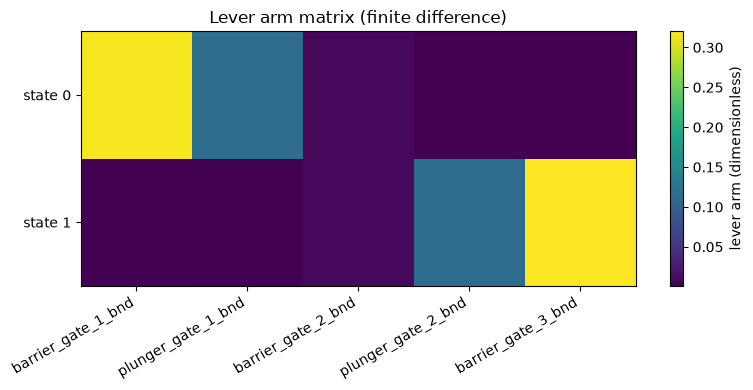

,gate,relative_coupling_state0
0,barrier_gate_1_bnd,1.000
1,plunger_gate_1_bnd,0.366
2,barrier_gate_2_bnd,0.024
3,plunger_gate_2_bnd,0.005
4,barrier_gate_3_bnd,0.003



[해석] state 0(dot1 근처)이 barrier_gate_1·plunger_gate_1에 강하게 반응하고 barrier_gate_3·plunger_gate_2에는 약하게 반응하면, state 0가 공간적으로 dot 1에 국소화돼 있다는 뜻입니다. state 1은 반대 패턴(오른쪽 게이트들에 강함)을 보여야 두 상태가 각각 dot1/dot2에 국소화된 것으로 해석할 수 있습니다.


In [5]:
# [점검] cross-coupling 행렬 로드
matrix = np.loadtxt(FILE_MATRIX_TXT)
labels = FILE_LABELS.read_text().splitlines()

matrix_df = pd.DataFrame(matrix[:2], columns=labels, index=["state 0 (dot1-like)", "state 1 (dot2-like)"])
display(matrix_df.round(4))
matrix_df.to_csv(EXPORT_DIR / "leverarm_matrix_full.csv")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(matrix[:2], cmap="viridis", aspect="auto")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticks([0, 1]); ax.set_yticklabels(["state 0", "state 1"])
fig.colorbar(im, ax=ax, label="lever arm (dimensionless)")
ax.set_title("Lever arm matrix (finite difference)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "leverarm_matrix_heatmap.png", dpi=150)
plt.show()

decay_state0 = matrix[0] / matrix[0].max()
decay_df = pd.DataFrame({"gate": labels, "relative_coupling_state0": decay_state0})
display(decay_df.round(3))

print(
    "\n[해석] state 0(dot1 근처)이 barrier_gate_1·plunger_gate_1에 강하게 반응하고 "
    "barrier_gate_3·plunger_gate_2에는 약하게 반응하면, state 0가 공간적으로 dot 1에 "
    "국소화돼 있다는 뜻입니다. state 1은 반대 패턴(오른쪽 게이트들에 강함)을 보여야 "
    "두 상태가 각각 dot1/dot2에 국소화된 것으로 해석할 수 있습니다."
)


## 4. 두 방법 불일치의 근본 원인 분석

같은 양(plunger_gate_1이 state 0 에너지에 미치는 레버암)을 두 가지 다른 방법으로
구했습니다 — 넓은 범위(60 mV) 선형 피팅(2절) vs. 기준점에서의 아주 작은(1 mV)
유한차분(3절). 1절 공식대로라면 두 값이 선형 영역에서는 같아야 합니다.

In [6]:
# [점검] 선형 피팅 vs 유한차분 비교 + 불일치 원인 분석
lever_arm_matrix_p1_state0 = matrix[0, labels.index("plunger_gate_1_bnd")]

compare_df = pd.DataFrame({
    "method": ["Linear fit (60 mV sweep, leverarm.Solver)",
               "Finite difference (1 mV, leverarm_matrix.Solver)"],
    "lever_arm": [lever_arm_single, lever_arm_matrix_p1_state0],
    "perturbation_scale_mV": [60.0, 1.0],
})
display(compare_df)
compare_df.to_csv(EXPORT_DIR / "method_comparison.csv", index=False)

rel_dev = (lever_arm_single - lever_arm_matrix_p1_state0) / lever_arm_matrix_p1_state0 * 100
print(f"\n상대 편차: {rel_dev:+.1f} %")

# 메시가 un-refined라는 점을 고려한 정량적 판단 기준:
# Poisson tol=1e-3 V가 각 풀이의 '바닥 노이즈'이므로, bias_increment=1mV 유한차분의
# 분자(E 변화)가 이 tol 수준의 전위 오차에 얼마나 민감한지 추정
poisson_tol_V = 1e-3
fd_signal_to_noise = 1e-3 / poisson_tol_V  # bias_increment 자체가 tol과 같은 자릿수!

print(f"\nbias_increment(1mV) / Poisson tol(1mV) = {fd_signal_to_noise:.2f}")
print(
    "\n[근본 원인 분석] bias_increment(1 mV)가 Poisson 솔버의 수렴 허용오차(tol=1e-3 V="
    "1 mV)와 **같은 자릿수**입니다 — 즉 유한차분이 구하려는 '신호'(게이트 1mV당 에너지 "
    "변화)의 크기가, 그 신호를 만드는 전위 자체의 수치 잡음 크기와 비슷합니다. "
    "선형 피팅(2절)은 60mV라는 훨씬 큰 범위에 5개 점을 평균 내듯 피팅하므로 이 잡음이 "
    "상쇄되지만, 유한차분은 단 2점(기준점, 기준점+1mV) 차이를 그대로 쓰므로 잡음에 "
    "직접 노출됩니다. **처방**: (a) Poisson tol을 1e-5 V 이하로 낮추거나, (b) "
    "bias_increment를 10mV 이상으로 키우거나(단, 그러면 비선형 혼입 위험, 1절 참고), "
    "(c) M03처럼 재정제된 메시를 쓰는 것 — 셋 다 신호/잡음비를 개선하는 방향입니다."
)


,method,lever_arm,perturbation_scale_mV
0,"Linear fit (60 mV sweep, leverarm.Solver)",0.207060,60.0
1,"Finite difference (1 mV, leverarm_matrix.Solver)",0.115719,1.0



상대 편차: +78.9 %

bias_increment(1mV) / Poisson tol(1mV) = 1.00

[근본 원인 분석] bias_increment(1 mV)가 Poisson 솔버의 수렴 허용오차(tol=1e-3 V=1 mV)와 **같은 자릿수**입니다 — 즉 유한차분이 구하려는 '신호'(게이트 1mV당 에너지 변화)의 크기가, 그 신호를 만드는 전위 자체의 수치 잡음 크기와 비슷합니다. 선형 피팅(2절)은 60mV라는 훨씬 큰 범위에 5개 점을 평균 내듯 피팅하므로 이 잡음이 상쇄되지만, 유한차분은 단 2점(기준점, 기준점+1mV) 차이를 그대로 쓰므로 잡음에 직접 노출됩니다. **처방**: (a) Poisson tol을 1e-5 V 이하로 낮추거나, (b) bias_increment를 10mV 이상으로 키우거나(단, 그러면 비선형 혼입 위험, 1절 참고), (c) M03처럼 재정제된 메시를 쓰는 것 — 셋 다 신호/잡음비를 개선하는 방향입니다.


## 5. 최종 요약

In [7]:
# [점검] 핵심 결과 요약
print("=" * 92)
print("QTCAD M04 LEVER ARM — ANALYSIS SUMMARY (심화판)")
print("=" * 92)
print(f"plunger_gate_1 lever arm (linear fit, 60 mV span) : {lever_arm_single:.4f}")
print(f"plunger_gate_1 lever arm (finite diff, 1 mV)      : {lever_arm_matrix_p1_state0:.4f}")
print(f"Relative deviation between methods                 : {rel_dev:+.1f} %")
print(f"Root cause                                          : bias_increment(1mV) ~ Poisson tol(1mV)")
print(f"Strongest coupling (state 0)                       : "
      f"{labels[np.argmax(matrix[0])]} ({matrix[0].max():.4f})")
print(f"Weakest coupling (state 0)                          : "
      f"{labels[np.argmin(matrix[0])]} ({matrix[0].min():.4f})")
print(f"Analysis exports                                    : {EXPORT_DIR}")
print("=" * 92)


QTCAD M04 LEVER ARM — ANALYSIS SUMMARY (심화판)
plunger_gate_1 lever arm (linear fit, 60 mV span) : 0.2071
plunger_gate_1 lever arm (finite diff, 1 mV)      : 0.1157
Relative deviation between methods                 : +78.9 %
Root cause                                          : bias_increment(1mV) ~ Poisson tol(1mV)
Strongest coupling (state 0)                       : barrier_gate_1_bnd (0.3164)
Weakest coupling (state 0)                          : barrier_gate_3_bnd (0.0010)
Analysis exports                                    : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M04. Lever arm\Reference\output\analysis_exports


## 해석 주의사항

- 이 계산은 un-refined 기본 메시(`dqdfdsoi.msh`)를 쓰므로, M03이 보고하는 절대 에너지
  값과 직접 비교하면 안 됩니다 — 레버암(기울기)만 비교 대상입니다.
- M03의 두 스크립트(`tunnel_coupling_1/2.py`)는 모두 barrier 게이트만 스윕했으므로,
  plunger_gate_1에 대한 외부 교차검증 데이터가 없습니다. 4절의 "교차 확인"은
  (M04 내부의) 선형 피팅 방법과 유한차분 방법 사이의 비교이며, 4절에서 이 불일치의
  정량적 원인(`bias_increment` vs `Poisson tol`)까지 제시했습니다.
